In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
cus_can = pd.read_csv('Customer_cancellation.csv')

In [3]:
cus_can.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,...,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Churned,Stayed,Unnamed: 36,Unnamed: 37,Unnamed: 38
0,0021-IKXGC,Female,72.0,No,0.0,San Marcos,0.0,1.0,Offer E,Yes,...,7.77,79.87,Joined,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0023-HGHWL,Male,67.0,No,0.0,Morgan Hill,0.0,1.0,NaN,No,...,0.00,25.10,Churned,Competitor,Competitor made better offer,NaN,NaN,NaN,NaN,NaN
2,0032-PGELS,Female,37.0,Yes,1.0,Palomar Mountain,1.0,1.0,NaN,No,...,0.00,30.50,Churned,Attitude,Attitude of service provider,NaN,NaN,NaN,NaN,NaN
3,0082-LDZUE,Male,54.0,No,0.0,Calistoga,0.0,1.0,Offer E,Yes,...,42.95,87.25,Joined,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0107-WESLM,Male,32.0,No,0.0,West Point,0.0,1.0,Offer E,Yes,...,31.77,51.62,Churned,Attitude,Attitude of support person,NaN,NaN,NaN,NaN,NaN


In [4]:
cus_can.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7045 entries, 0 to 7044
Data columns (total 39 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   float64
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   float64
 5   City                               7043 non-null   object 
 6   Number of Referrals                7043 non-null   float64
 7   Tenure in Months                   7043 non-null   float64
 8   Offer                              3166 non-null   object 
 9   Phone Service                      7043 non-null   object 
 10  Avg Monthly Long Distance Charges  6361 non-null   float64
 11  Multiple Lines                     6361 non-null   objec

In [5]:
#Kiểm tra các giá trị null trong dữ liệu
cus_can.isnull().sum()

Customer ID                             2
Gender                                  2
Age                                     2
Married                                 2
Number of Dependents                    2
City                                    2
Number of Referrals                     2
Tenure in Months                        2
Offer                                3879
Phone Service                           2
Avg Monthly Long Distance Charges     684
Multiple Lines                        684
Internet Service                        2
Internet Type                        1528
Avg Monthly GB Download              1528
Online Security                      1528
Online Backup                        1528
Device Protection Plan               1528
Premium Tech Support                 1528
Streaming TV                         1528
Streaming Movies                     1528
Streaming Music                      1528
Unlimited Data                       1528
Contract                          

In [6]:
#Xóa các cột: 'Churned', 'Stayed', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38'. vì không có dữ liệu nên không có giá trị để phân tích
cus_can = cus_can.drop(columns=['Churned', 'Stayed', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38'])

In [7]:
#Kiểm tra các dòng không có dữ liệu
cus_can[cus_can.isnull().all(axis=1)]
#Xóa các dòng vừa kiểm tra và không cso dữ liệu nên không có giá trị để phân tích
cus_can = cus_can.dropna(how='all')
cus_can.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                     1526
Streaming Music                      1526
Unlimited Data                       1526
Contract                          

In [8]:
#Xem qua các giá trị null thì em thấy các cột này đều có 1526 giá trị null nên em gom lại để kiểm tra
cols_of_Internet_Service = ['Internet Type', 'Online Security',
                            'Online Backup','Device Protection Plan','Premium Tech Support','Streaming TV',
                            'Streaming Movies', 'Streaming Music','Unlimited Data']
for cols in cols_of_Internet_Service:
    print(f'cột {cols} có', cus_can[cus_can['Internet Service'] == 'No'][cols].isnull().sum(),'giá trị null')

cột Internet Type có 1526 giá trị null
cột Online Security có 1526 giá trị null
cột Online Backup có 1526 giá trị null
cột Device Protection Plan có 1526 giá trị null
cột Premium Tech Support có 1526 giá trị null
cột Streaming TV có 1526 giá trị null
cột Streaming Movies có 1526 giá trị null
cột Streaming Music có 1526 giá trị null
cột Unlimited Data có 1526 giá trị null


In [9]:
#Với kết quả trên thì em thấy được là 1526 giá trị null trong các cột này không có vì khách hàng không sử dụng 'Internet Service' với giá trị trong 'Internet Service' là 'No'
#Nên em sẽ sửa lại các giá trị null này thành 'No Internet Service'
#các giá trị null trong cột 'Avg Monthly GB Download' = 0
cus_can[cols_of_Internet_Service] = cus_can[cols_of_Internet_Service].fillna('No Internet Service')
cus_can['Avg Monthly GB Download'] = cus_can['Avg Monthly GB Download'].fillna(0)

In [10]:
#Tiếp theo em kiểm tra 2 cột có 682 giá trị null
cols_of_Phone_Service = ['Avg Monthly Long Distance Charges','Multiple Lines']
for cols in cols_of_Phone_Service:
    print(f'cột {cols} có', cus_can[cus_can['Phone Service'] == 'No'][cols].isnull().sum(),'giá trị null')

cột Avg Monthly Long Distance Charges có 682 giá trị null
cột Multiple Lines có 682 giá trị null


In [11]:
#Với kết quả trên thì em thấy được là 682 giá trị null trong các cột này không có vì khách hàng không sử dụng 'Phone Service' với giá trị trong 'Phone Service' là 'No'
#Nên em sẽ sửa lại giá trị null trong cột 'Multiple Lines' này thành 'No Phone Service' và các giá trị null trong cột 'Avg Monthly Long Distance Charges' = 0
cus_can['Multiple Lines'] = cus_can['Multiple Lines'].fillna('No Phone Service')
cus_can['Avg Monthly Long Distance Charges'] = cus_can['Avg Monthly Long Distance Charges'].fillna(0)

In [12]:
#Giá trị null trong Cột 'offer' cho thấy khách hàng không được hỗ trợ bởi bất cứ ưu đãi nào nên các giá trị null sẽ được thay bằng 'No Offer'
cus_can['Offer'] = cus_can['Offer'].fillna('No Offer')

In [13]:
cus_can['Customer Status'].value_counts()

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

In [14]:
#Kiểm tra các giá trị null trong 2 cột Churn
print('cột Churn Category có', cus_can[(cus_can['Customer Status'] == 'Stayed') | (cus_can['Customer Status'] == 'Joined')]['Churn Category'].isnull().sum(),'giá trị null')
print('cột Churn Reason có', cus_can[(cus_can['Customer Status'] == 'Stayed') | (cus_can['Customer Status'] == 'Joined')]['Churn Reason'].isnull().sum(),'Giá trị null')
#Qua kiểm tra thì em thấy các giá trị null này hoàn toàn hợp lí vì khách hàng vẫn còn đang dùng dịch vụ nên không có lí do rời đi nên sẽ giữ nghuyên giá trị này

cột Churn Category có 5174 giá trị null
cột Churn Reason có 5174 Giá trị null


In [15]:
#Gom nhóm cột Age để thuận tiện cho phân tích
cus_can['Age Group'] = pd.cut(
    cus_can['Age'],
    bins=[18, 34, 49, 69, float('inf')],
    labels=['18-34', '35-49', '50-69', '70+'],
    right= True)

In [16]:
#Gom nhóm cột Tenure in Months với:
# 'New' 1–12 Khách mới, đang trong giai đoạn thử nghiệm
# 'Developing' 13–24 Bắt đầu gắn bó
# 'Established' 25–48 Đã quen dịch vụ
# 'Loyal' 49–72 Khách trung thành, gắn bó lâu dài
cus_can['Tenure Group'] = pd.cut(
    cus_can['Tenure in Months'],
    bins=[0, 12, 24, 48, 72],
    labels=['New', 'Developing', 'Established', 'Loyal'],
    right= True)

In [17]:
cus_can.describe()

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,1.951867,32.386767,22.958954,20.515405,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,3.001199,24.542061,15.448113,20.418940,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,0.000000,9.000000,9.210000,3.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,0.000000,29.000000,22.890000,17.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,3.000000,55.000000,36.395000,27.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [18]:
#kiểm tra các giá trị âm trong cột 'Monthly Charge'
cus_can[cus_can['Monthly Charge'] < 0]['Monthly Charge'].value_counts()

Monthly Charge
-4.0     17
-7.0     16
-1.0     13
-3.0     13
-10.0    13
-8.0     12
-5.0     11
-2.0     10
-9.0      9
-6.0      6
Name: count, dtype: int64

In [19]:
#theo em thì cột 'Monthly Charge' không thể có giá trị âm và có thể là nhập liệu sai nên em sẽ sửa lại các giá trị âm thành dương
cus_can['Monthly Charge'] = cus_can['Monthly Charge'].abs()

In [20]:
#Kiểm tra lại dữ liệu null
cus_can.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Number of Referrals                     0
Tenure in Months                        0
Offer                                   0
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                        0
Internet Type                           0
Avg Monthly GB Download                 0
Online Security                         0
Online Backup                           0
Device Protection Plan                  0
Premium Tech Support                    0
Streaming TV                            0
Streaming Movies                        0
Streaming Music                         0
Unlimited Data                          0
Contract                          

In [21]:
#Kiểm tra lại dữ liệu
cus_can.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7042
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Customer ID                        7043 non-null   object  
 1   Gender                             7043 non-null   object  
 2   Age                                7043 non-null   float64 
 3   Married                            7043 non-null   object  
 4   Number of Dependents               7043 non-null   float64 
 5   City                               7043 non-null   object  
 6   Number of Referrals                7043 non-null   float64 
 7   Tenure in Months                   7043 non-null   float64 
 8   Offer                              7043 non-null   object  
 9   Phone Service                      7043 non-null   object  
 10  Avg Monthly Long Distance Charges  7043 non-null   float64 
 11  Multiple Lines                     7043 non-null

In [22]:
#Đã hoàn thành bước làm sạch dữ liệu
cus_can.to_csv('Customer_cancellation_cleaned.csv')

In [23]:
cus = pd.read_csv('Customer_cancellation_cleaned.csv')

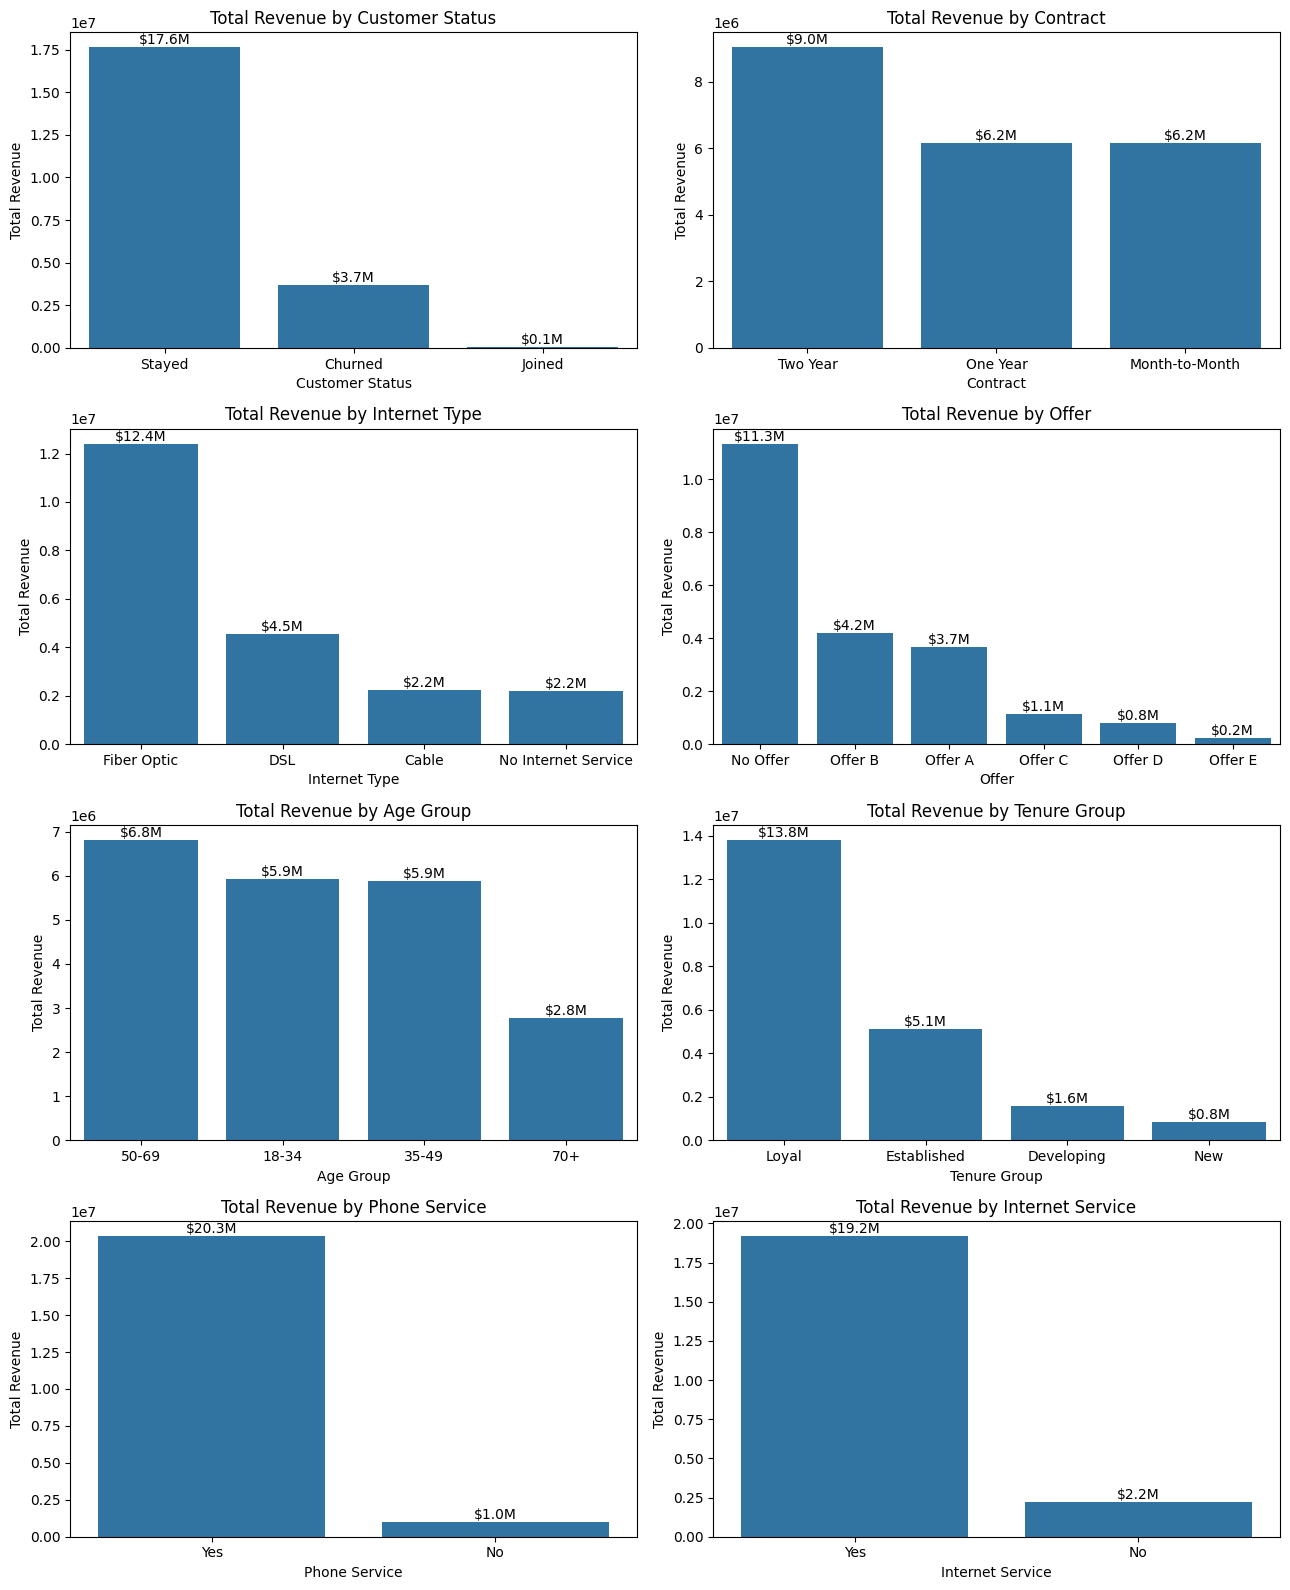

In [24]:
#Các biểu đồ tổng quan theo Total Revenue
cols_for_revenue = ['Customer Status','Contract', 'Internet Type', 'Offer','Age Group', 'Tenure Group', 'Phone Service', 'Internet Service']
n_col = 2
n_row = int(round(len(cols_for_revenue) / n_col, 0))

plt.figure(figsize=(13, 4 * n_row))

for (n, cat) in enumerate(cols_for_revenue):
    ax = plt.subplot(n_row, n_col, n + 1)
    summary = cus.groupby(cat)['Total Revenue'].sum().reset_index().sort_values('Total Revenue',ascending=False)
    sns.barplot(data=summary, x=cat, y='Total Revenue')
    plt.title(f'Total Revenue by {cat}')
    plt.xticks()

    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'${bar.get_height()/1_000_000:.1f}M',
            ha='center', va='bottom',
            fontsize=10)

plt.tight_layout()
plt.show()

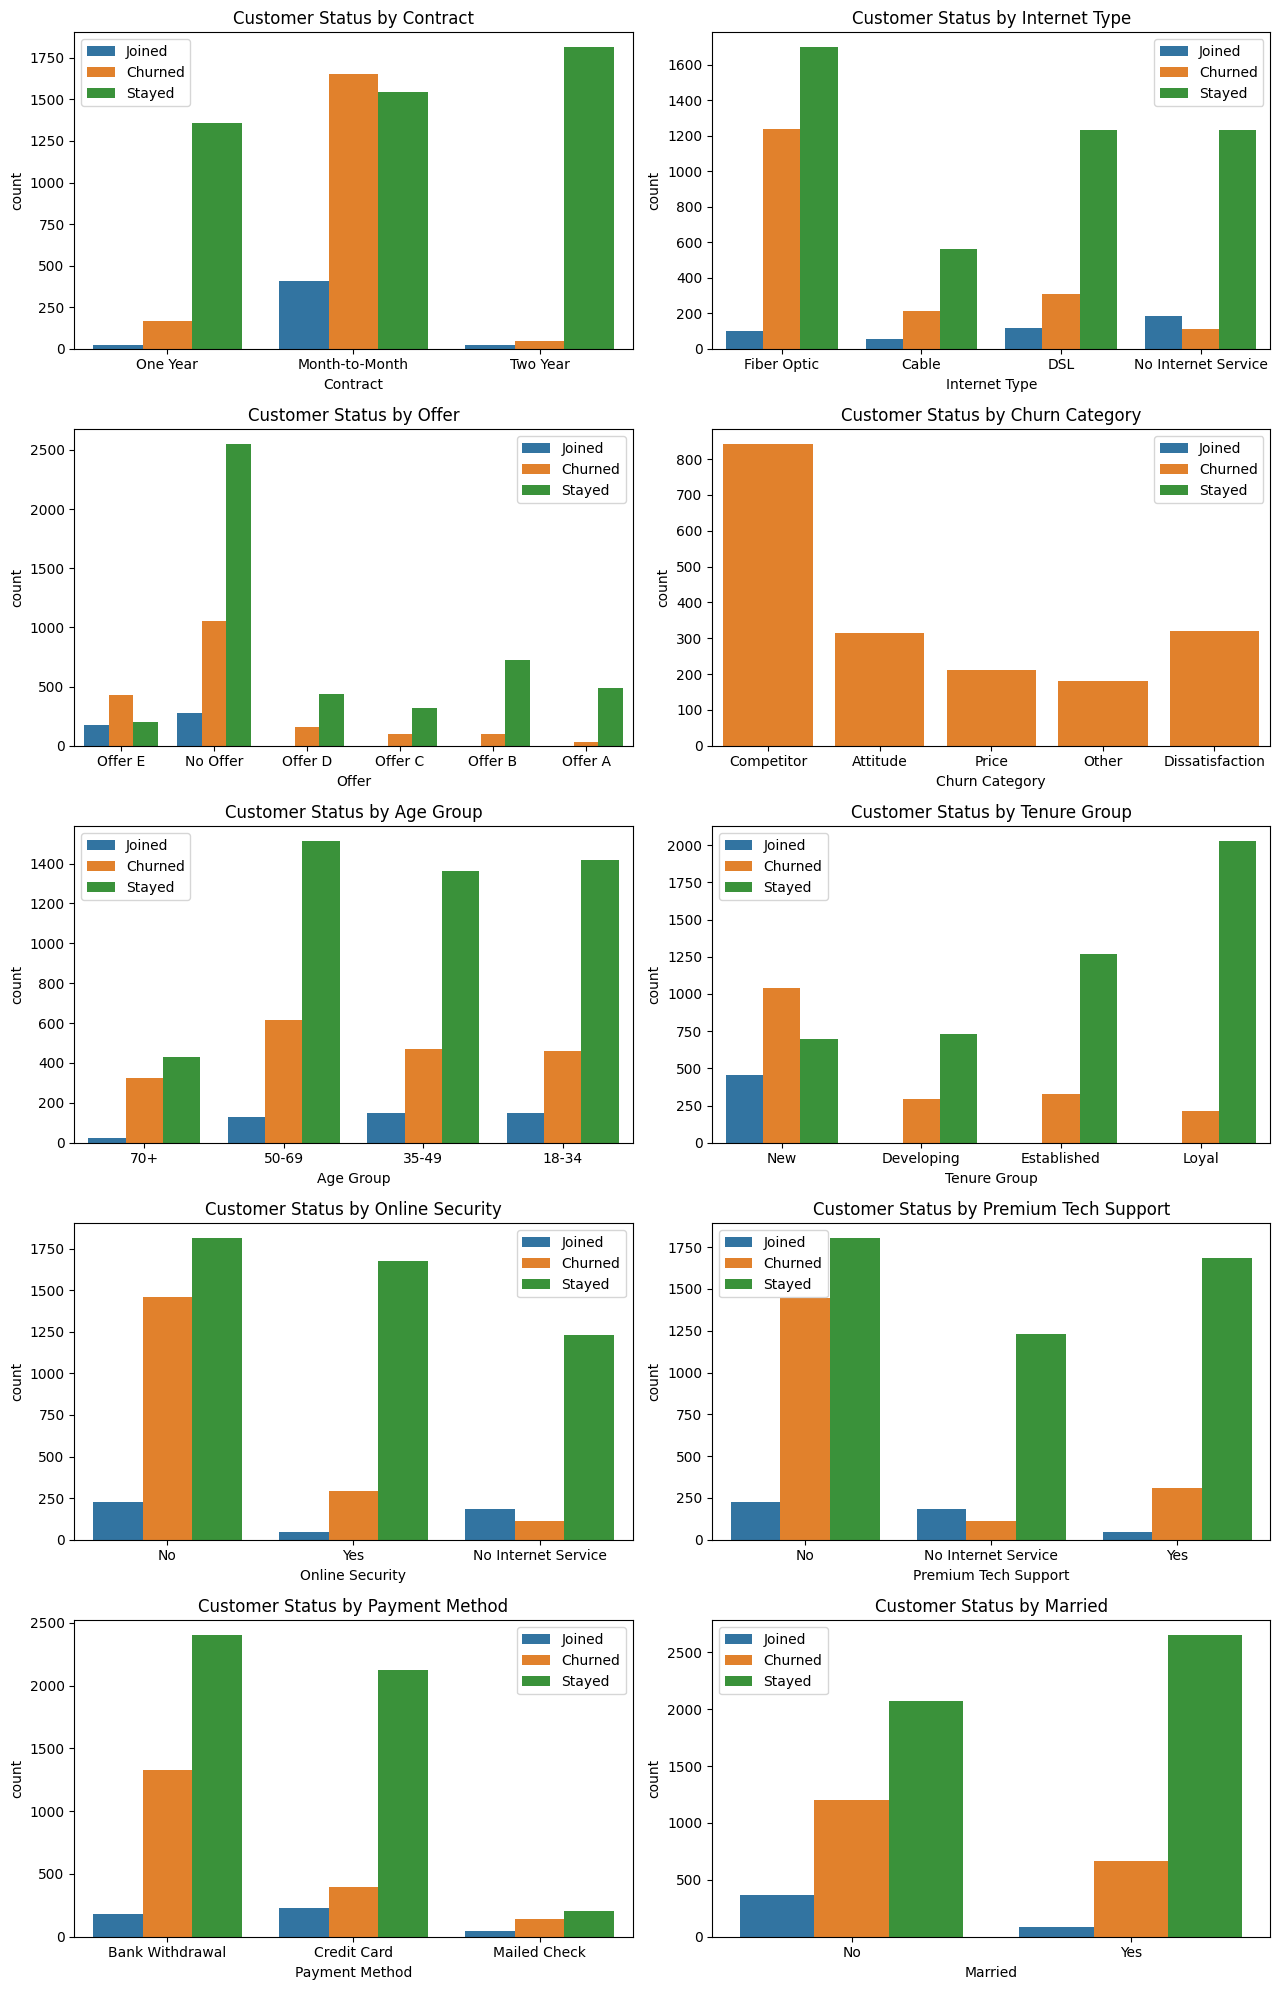

In [25]:
#Các biểu đồ tổng quan theo Customer Status
cols_for_churn = ['Contract', 'Internet Type', 'Offer', 'Churn Category','Age Group', 'Tenure Group', 'Online Security',
                  'Premium Tech Support', 'Payment Method', 'Married']

n_col = 2
n_row = int(round(len(cols_for_churn) / n_col, 0))

plt.figure(figsize=(13, 4*n_row))

for (n, cat) in enumerate(cols_for_churn):
    ax = plt.subplot(n_row, n_col, n + 1)
    sns.countplot(data=cus, x=cat, hue='Customer Status')
    plt.title(f'Customer Status by {cat}')
    plt.xticks()
    plt.legend()

plt.tight_layout()
plt.show()

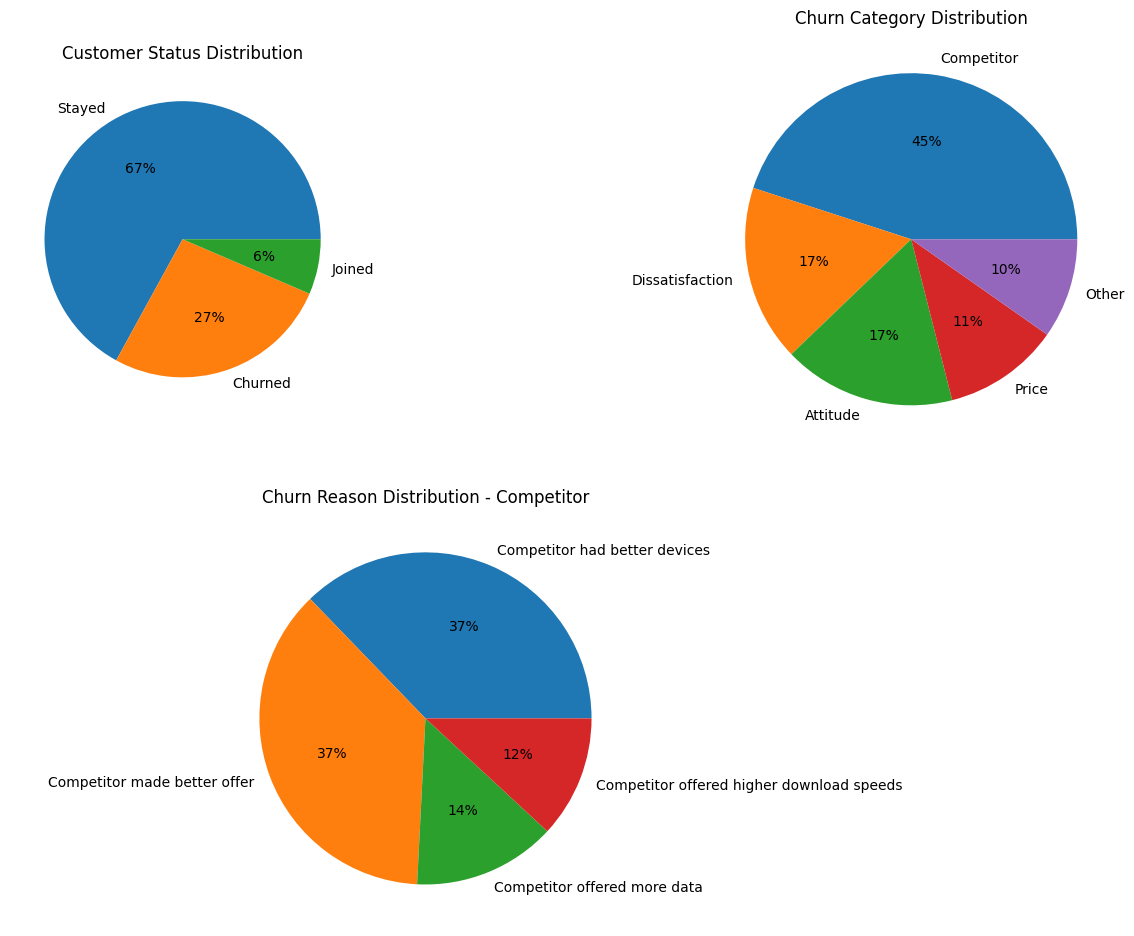

In [26]:
#3 biểu đồ này phân tích sâu về tỉ lệ Churned
plt.figure(figsize=(14, 10))
#Tỉ lệ phân bố của 3 trạng thái khách hàng
plt.subplot(2, 3, 1)
status_counts = cus['Customer Status'].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.0f%%')
plt.title('Customer Status Distribution')

#Tỉ lệ phân bố của nhóm lí do khách hàng rời đi
plt.subplot(2, 3, (2,3))
churn_counts = cus['Churn Category'].value_counts()
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.0f%%')
plt.title('Churn Category Distribution')

#Tỉ lệ phân bố của lí do khách hàng rời đi theo nhóm Competitor
plt.subplot(2, 3, (4,5))
competitor_counts = cus[cus['Churn Category'] == 'Competitor']['Churn Reason'].value_counts()
plt.pie(competitor_counts, labels=competitor_counts.index, autopct='%1.0f%%')
plt.title('Churn Reason Distribution - Competitor')

plt.tight_layout(pad=3.0)
plt.show()

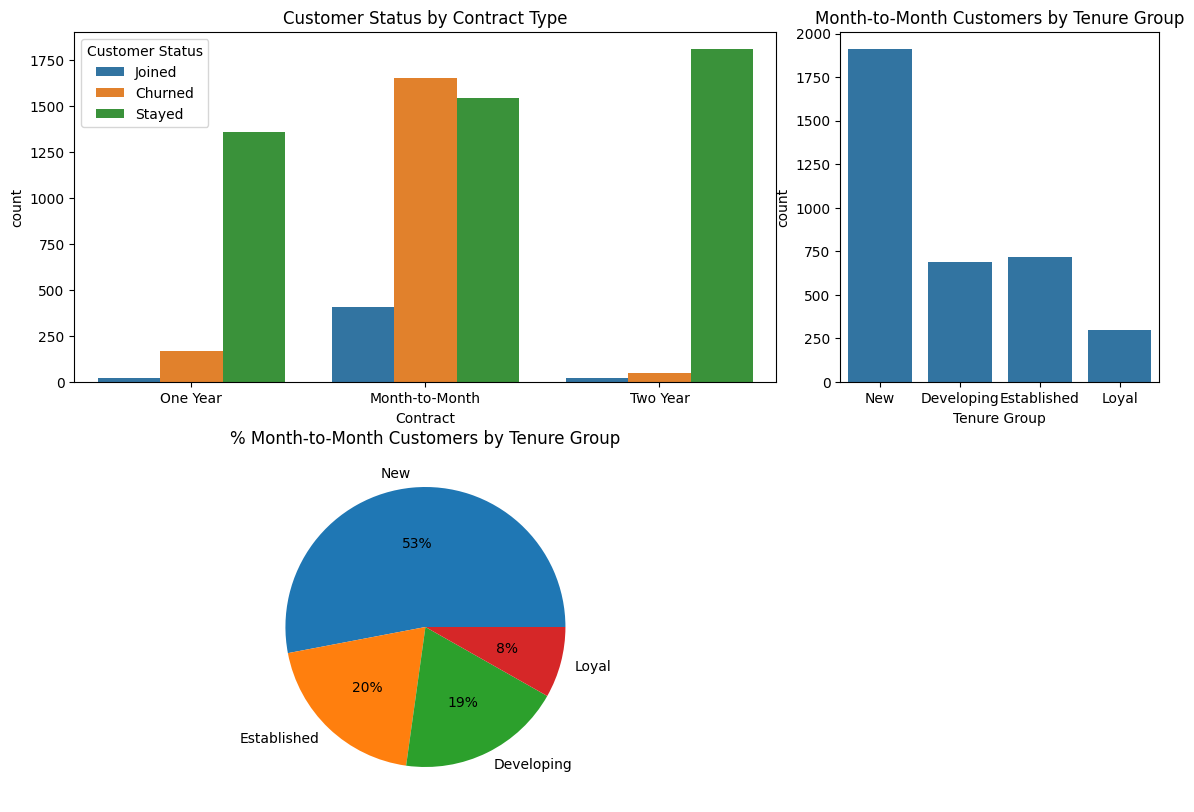

<Figure size 640x480 with 0 Axes>

In [27]:
#3 biểu đồ này phân tích sâu về mmonth_to_month contract vì số lượng churned rất lớn
plt.figure(figsize=(14, 10))
#Số lượng trạng thái khách hàng theo contract cho thấy month-to-month có số lượng khách rời đi rất cao
plt.subplot(2, 3, (1,2))
sns.countplot(data=cus, x=cus['Contract'], hue='Customer Status')
plt.title('Customer Status by Contract Type')

#Khách hàng month-to-month theo Tenure Group
plt.subplot(2, 3, 3)
month_to_month = cus[cus['Contract'] == 'Month-to-Month']
sns.countplot(data=month_to_month, x=month_to_month['Tenure Group'])
plt.title('Month-to-Month Customers by Tenure Group')

#Tỉ lệ khách hàng month-to-month theo Tenure Group
plt.subplot(2, 3, (4, 5))
tenure_counts = month_to_month['Tenure Group'].value_counts()
plt.pie(tenure_counts, labels=tenure_counts.index, autopct='%1.0f%%')
plt.title('% Month-to-Month Customers by Tenure Group')
plt.show()

plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
#70+ %Churn
#Online Security 85%
#Online Backup 68%
#Device Protect Plan 67%
#Premium Tech Support 87%
#Streaming TV 53%
#Streaming Movies 49%

In [ ]:
cột Internet Type có 1526 giá trị null
cột Online Security có 1526 giá trị null
cột Online Backup có 1526 giá trị null
cột Device Protection Plan có 1526 giá trị null
cột Premium Tech Support có 1526 giá trị null
cột Streaming TV có 1526 giá trị null
cột Streaming Movies có 1526 giá trị null
cột Streaming Music có 1526 giá trị null
cột Unlimited Data có 1526 giá trị null